# Moving application of ShellSIM from 1D time series data to complex 4D gridded dataset

Needed Variables 

T_timeseries=  Temperature Time series  
S_timeseries=  Practical Salinity Time series  
Chl_timeseries= Chlorophyll Time series  
POC_timeseries= Particulate Organic Carbon Time series  
POM_timeseries=  Particulate Organic Matter Time series  
TPM_timeseries= Total Particulate Matter   Time series  

In [1]:

import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import pandas as pd


import netCDF4
from dask.diagnostics import ProgressBar
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear


In [2]:
# ============================================================
# TIME HORIZON DEFINITION
# ============================================================
# Defines the simulation period as a daily DatetimeIndex.
# time_horizon_len is the number of forward-Euler steps the
# model wrapper will execute per pixel. This is also the length
# of every time-series array passed into run_fabm_at_point_full.


# Define the integration time period 
start = '01-06-2021'
end = '12-06-2021'
time_horizon = pd.date_range(start=start, end=end, freq='1d')
time_horizon_len = len(time_horizon)
time_horizon_len


335

In [3]:
# ============================================================
# CHUNKING CONFIG AND load_nc_file HELPER FUNCTION
# ============================================================
# chunking_config partitions the 3-D (time, lat, lon) arrays
# into Dask tiles. time=-1 means the ENTIRE time axis stays in
# one chunk — required because ShellSIM is a sequential time-
# stepping model and cannot be split along the time axis.
#
# Chunk-size tuning note:
#   lat=80, lon=110 are good starting values. Each chunk is
#   approximately 80 * 110 * 335 * 8 bytes ~ 236 MB per
#   variable. If you have limited RAM, reduce to lat=40,
#   lon=55 (~ 59 MB per variable).
#   Rule of thumb: keep each chunk at or below ~100 MB.
#
# load_nc_file: attempts to open a real netCDF file; if the
# file is missing it generates synthetic random data on the
# same grid as the first real dataset. This fallback lets the
# notebook run end-to-end on machines that only have partial
# data (useful for development and testing).

#  Lat lon chunking method
chunking_config={'time': -1, 'latitude': 80, 'longitude': 110}
# Earth's radius in kilometers (used for converting degrees to distance)
# The mean radius is a good approximation for surface area calculation.
EARTH_RADIUS_KM = 6371.0 # km
_GLOBAL_COORDS = None


def load_nc_file(file_path, var_name_in_file, chunking_config=None):
    """
    Loads a NetCDF file or creates a fake one if not found.
    """
    global _GLOBAL_COORDS
    fake_filename = f'{var_name_in_file}_gridded_FAKE.nc'
    
    if os.path.exists(file_path):
        print(f"Successfully loaded: {var_name_in_file}")
        # Load the dataset
        ds = xr.open_dataset(file_path, chunks=chunking_config)
        # --- START COORDINATE & AREA CALCULATION BLOCK ---
        try:
            # 1. Get Lat/Lon coordinates safely
            lat_coords = ds['latitude'].values if 'latitude' in ds.coords else ds['lat'].values
            lon_coords = ds['longitude'].values if 'longitude' in ds.coords else ds['lon'].values
    
            # Get time coordinate if it exists
            time_coords = ds['time'].values if 'time' in ds.coords else None
            
            # Store global coordinates from the FIRST real dataset loaded
            if _GLOBAL_COORDS is None:
                _GLOBAL_COORDS = {
                    'lat': lat_coords,
                    'lon': lon_coords,
                    'time': time_coords,  
                    'lat_name': 'latitude' if 'latitude' in ds.coords else 'lat',
                    'lon_name': 'longitude' if 'longitude' in ds.coords else 'lon'
                }
                print(f"✅ Set global coordinate reference from: {var_name_in_file}")
            
        except KeyError:
            print("❌ ERROR: The dataset is missing coordinate variables. Expected ('latitude' or 'lat') and ('longitude' or 'lon').")
            return ds

        # Calculate bounds and ranges
        lat_min, lat_max = lat_coords.min(), lat_coords.max()
        lon_min, lon_max = lon_coords.min(), lon_coords.max()

        lat_range_deg = lat_max - lat_min
        lon_range_deg = lon_max - lon_min
        
        # 2. Convert ranges to distance
        lat_distance_km = lat_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360)
        
        mid_lat_rad = np.deg2rad((lat_max + lat_min) / 2)
        lon_distance_km = lon_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360) * np.cos(mid_lat_rad)
        
        # 3. Calculate Approximate Area
        approx_area_sq_km = lat_distance_km * lon_distance_km
        
        print(f"🗺️ Geographic Coverage:")
        print(f"  BBOX (xMin, yMin, xMax, yMax)")
        print(f"  BBOX ({lon_min:.2f}, {lat_min:.2f}, {lon_max:.2f}, {lat_max:.2f})")
        print(f"  Lat Range: {lat_min:.2f}° to {lat_max:.2f}° ({lat_range_deg:.2f}°)")
        print(f"  Lon Range: {lon_min:.2f}° to {lon_max:.2f}° ({lon_range_deg:.2f}°)")
        print(f"  Approximate Area: {approx_area_sq_km:,.0f} km²")
        print("---------------------------------------------------\n")
        
        return ds
    
    if os.path.exists(fake_filename):
        print(f"Using existing fake dataset: {fake_filename}\n")
        return xr.open_dataset(fake_filename, chunks=chunking_config)

    # Check if we have global coordinates from a real dataset
    if _GLOBAL_COORDS is None:
        print("⚠️ WARNING: No real dataset loaded yet. Creating fake data with default coordinates.")
        # Default fallback coordinates (your original values)
        fake_lats = np.linspace(40, 50, 100)
        fake_lons = np.linspace(-10, 0, 100)
        time_horizon = np.arange(0, 30)  # Default 30 time steps
        lat_name = 'latitude'
        lon_name = 'longitude'
    else:
        print(f"📍 Creating fake data matching global coordinate reference")
        fake_lats = _GLOBAL_COORDS['lat']
        fake_lons = _GLOBAL_COORDS['lon']
        lat_name = _GLOBAL_COORDS['lat_name']
        lon_name = _GLOBAL_COORDS['lon_name']
        
        # Use time from real dataset if available, otherwise default
        if _GLOBAL_COORDS.get('time') is not None:  # ← CHANGED to .get()
            time_horizon = _GLOBAL_COORDS['time']
        else:
            time_horizon = np.arange(0, 30)
    
    time_horizon_len = len(time_horizon)
    
    # Create fake data with matching dimensions
    fake_data = np.random.rand(time_horizon_len, len(fake_lats), len(fake_lons))
    
    fake_gridded_dataset = xr.Dataset(
        {var_name_in_file: (['time', lat_name, lon_name], fake_data)},
        coords={'time': time_horizon, lat_name: fake_lats, lon_name: fake_lons}
    )
    
    fake_gridded_dataset.to_netcdf(fake_filename)
    print(f"✅ Saved fake dataset to: {fake_filename}")
    print(f"   Coordinates: time[{time_horizon_len}], {lat_name}[{len(fake_lats)}], {lon_name}[{len(fake_lons)}]")
    print(f"   BBOX ({fake_lons.min():.2f}, {fake_lats.min():.2f}, {fake_lons.max():.2f}, {fake_lats.max():.2f})\n")
    
    return xr.open_dataset(fake_filename, chunks=chunking_config)

    

In [4]:
# ============================================================
# INPUT FILE PATHS AND VARIABLE NAMES
# ============================================================
# Each environmental forcing variable lives in its own netCDF
# downloaded from CMEMS. Setting a path to a non-existent file
# triggers the fake-data fallback in load_nc_file so the full
# pipeline can be tested without all data present.
# To use real data: replace the path strings with valid paths.

# Define datasets to be read and used for model
poc_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc"
poc_var_name = 'poc'  # variable name inside poc.nc

salinity_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc"
salinity_var_name = 'sos' # variable name inside salinity.nc

# Fake data generation to be triggered in the 'except' block of load_nc_file if path doesn't exist
temp_file_path = 'non_existent_temp.nc'
temp_var_name = 'temperature' # variable name inside temperature.nc

chl_file_path = 'non_existent_chl.nc'
chl_var_name = 'chl'

pom_file_path = 'non_existent_pom.nc'
pom_var_name = 'pom'

tpm_file_path = 'non_existent_tpm.nc'
tpm_var_name = 'tpm'


In [5]:
# ============================================================
# LOAD ALL SIX FORCING DATASETS
# ============================================================
# Calls load_nc_file for each variable. The first successfully
# loaded real dataset sets _GLOBAL_COORDS (the master grid);
# all subsequent fake datasets are generated on that same
# lat/lon/time grid so all arrays are automatically aligned.
# After this cell we have six lazy Dask-backed DataArrays;
# no large data has been read into RAM yet.

# Load all datasets
print("Loading datasets...\n")
# view bbox with http://bboxfinder.com/#30.060000,-12.940000,69.940000,41.940000
ds_poc = load_nc_file(poc_file_path, poc_var_name)
ds_sal = load_nc_file(salinity_file_path, salinity_var_name)
ds_temp = load_nc_file(temp_file_path, temp_var_name)
ds_chl = load_nc_file(chl_file_path, chl_var_name)
ds_pom = load_nc_file(pom_file_path, pom_var_name)
ds_tpm = load_nc_file(tpm_file_path, tpm_var_name)

Loading datasets...

Successfully loaded: poc


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc: Operation not supported


✅ Set global coordinate reference from: poc
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.88, 30.12, 41.88, 69.88)
  Lat Range: 30.12° to 69.88° (39.75°)
  Lon Range: -12.88° to 41.88° (54.75°)
  Approximate Area: 17,296,519 km²
---------------------------------------------------

Successfully loaded: sos


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc: Operation not supported


🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.94, 30.06, 41.94, 69.94)
  Lat Range: 30.06° to 69.94° (39.88°)
  Lon Range: -12.94° to 41.94° (54.88°)
  Approximate Area: 17,390,524 km²
---------------------------------------------------

Using existing fake dataset: temperature_gridded_FAKE.nc

Using existing fake dataset: chl_gridded_FAKE.nc

Using existing fake dataset: pom_gridded_FAKE.nc

Using existing fake dataset: tpm_gridded_FAKE.nc



In [6]:
# ============================================================
# COORDINATE ALIGNMENT SETUP
# ============================================================
# Different CMEMS products can use slightly different lat/lon
# grids. We designate the POC dataset as the master reference
# and will interpolate all other variables onto it. This
# prevents dimension-mismatch errors in the model run.

# Align coordinates - using POC data as reference
# Grid alignment using ds_poc as the reference grid and interpolating all other variables to it, 
# as a way to handle mismatched grids.
print("Aligning coordinates...")
ref_lats = ds_poc.latitude
ref_lons = ds_poc.longitude


Aligning coordinates...


In [7]:
# ============================================================
# INTERPOLATE ALL VARIABLES TO A COMMON DAILY GRID
# ============================================================
# Some products are weekly (POC) or have slightly shifted grids.
# xarray .interp() fills gaps via linear interpolation in time
# and bilinear interpolation in space.
# fill_value='extrapolate' avoids NaN edges at domain borders.
#
# For 4-D products (with a depth dimension) we first select the
# surface layer with .sel(depth=0, method='nearest') because
# ShellSIM is a surface model.
#
# Result: ds_daily is a single lazy Dataset with 6 variables on
# a unified (time, latitude, longitude) grid ready for the model.

interp_kwargs = {'fill_value': 'extrapolate'}

# For 4D variables: Select first depth values -  Select a single depth level and interpolate 
# use .sel(depth=0, method='nearest') to grab the surface layer
poc_daily = ds_poc[poc_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
sal_daily = ds_sal[salinity_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Process 3D variables (datasets with no depth)
temp_daily = ds_temp[temp_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
chl_daily = ds_chl[chl_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
pom_daily = ds_pom[pom_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
tpm_daily = ds_tpm[tpm_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Merge into a single dataset
ds_daily_original = xr.Dataset({
    'salinity': sal_daily,
    'POC': poc_daily,
    'temperature': temp_daily,
    'Chl': chl_daily,
    'POM': pom_daily,
    'TPM': tpm_daily
})

print("Merged daily dataset")
ds_daily_original


Merged daily dataset


<xarray.Dataset> Size: 566MB
Dimensions:      (time: 335, latitude: 160, longitude: 220)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 640B 30.12 30.38 30.62 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 880B -12.88 -12.62 -12.38 ... 41.62 41.88
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 94MB 40.02 38.56 ... 52.49
    POC          (time, latitude, longitude) float64 94MB nan nan ... nan nan
    temperature  (time, latitude, longitude) float64 94MB -3.064 ... 3.512
    Chl          (time, latitude, longitude) float64 94MB -2.911 ... -3.463
    POM          (time, latitude, longitude) float64 94MB 1.986 -5.817 ... 17.44
    TPM          (time, latitude, longitude) float64 94MB 3.038 ... -15.52

In [8]:
# ============================================================
# SPATIAL SUBSETTING HELPER: subset_ds
# ============================================================
# Trims the full global/regional domain to a user-defined
# bounding box (min_lon, min_lat, max_lon, max_lat).
# Smaller domain = fewer pixels = faster model runs and lower
# memory usage. Use bboxfinder.com to find your bbox coords.

def subset_ds(ds: xr.Dataset, bbox: tuple) -> xr.Dataset:
    """
    Subsets an xarray.Dataset to a given geographic bounding box.
    The function assumes the dataset has 'latitude' and 'longitude'
    coordinates.
    Args:
        ds (xr.Dataset): The dataset to subset.
        bbox (tuple): A tuple containing the bounding box in the
                      format (min_lon, min_lat, max_lon, max_lat).
    Returns:
        xr.Dataset: The spatially subsetted dataset.
    """
    # Unpack the bounding box
    min_lon, min_lat, max_lon, max_lat = bbox

    # Use the .sel() method with slice() to select the data
    # within the bounding box. This is the standard xarray way
    # to select a range of coordinate values.
    subset = ds.sel(
        latitude=slice(min_lat, max_lat),
        longitude=slice(min_lon, max_lon)
    )

    return subset

In [9]:
ds_daily_full = ds_daily_original.copy()

In [10]:
# ============================================================
# APPLY GEOGRAPHIC BOUNDING BOX TO TRIM THE DOMAIN
# ============================================================
# Reduces ds_daily to the North Sea / Skagerrak region of
# interest (~65 x 92 pixels instead of 160 x 220).
# Adjust the bbox tuple to target a different region.
# Verify extent at: http://bboxfinder.com
# whole_dataset bbox = (7.910156, 53.041213, 31.025391, 69.364831)

# subset entire dataset
# 7.910156,53.041213,31.025391,69.364831
# http://bboxfinder.com/#53.041213,7.910156,69.364831,31.025391
# bbox = (7.910156, 53.041213, 31.025391, 69.364831)
bbox = (-17.929688,63.233627,18.281250,71.216075)

ds_daily_subset = subset_ds(ds_daily_original, bbox)
ds_daily_subset

<xarray.Dataset> Size: 54MB
Dimensions:      (time: 335, latitude: 27, longitude: 125)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 108B 63.38 63.62 63.88 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 500B -12.88 -12.62 -12.38 ... 17.88 18.12
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 9MB 2.023 0.9727 ... 83.93
    POC          (time, latitude, longitude) float64 9MB nan nan nan ... nan nan
    temperature  (time, latitude, longitude) float64 9MB 1.847 -3.149 ... 0.342
    Chl          (time, latitude, longitude) float64 9MB -0.9242 ... 0.2504
    POM          (time, latitude, longitude) float64 9MB -2.779 ... 3.841
    TPM          (time, latitude, longitude) float64 9MB 3.611 12.88 ... -10.6

In [11]:
# Data full or subset 

# ds_daily =  ds_daily_full  # <-- use the full dataset
ds_daily = ds_daily_subset  # <--  spatially subsetted version instead of the full dataset  



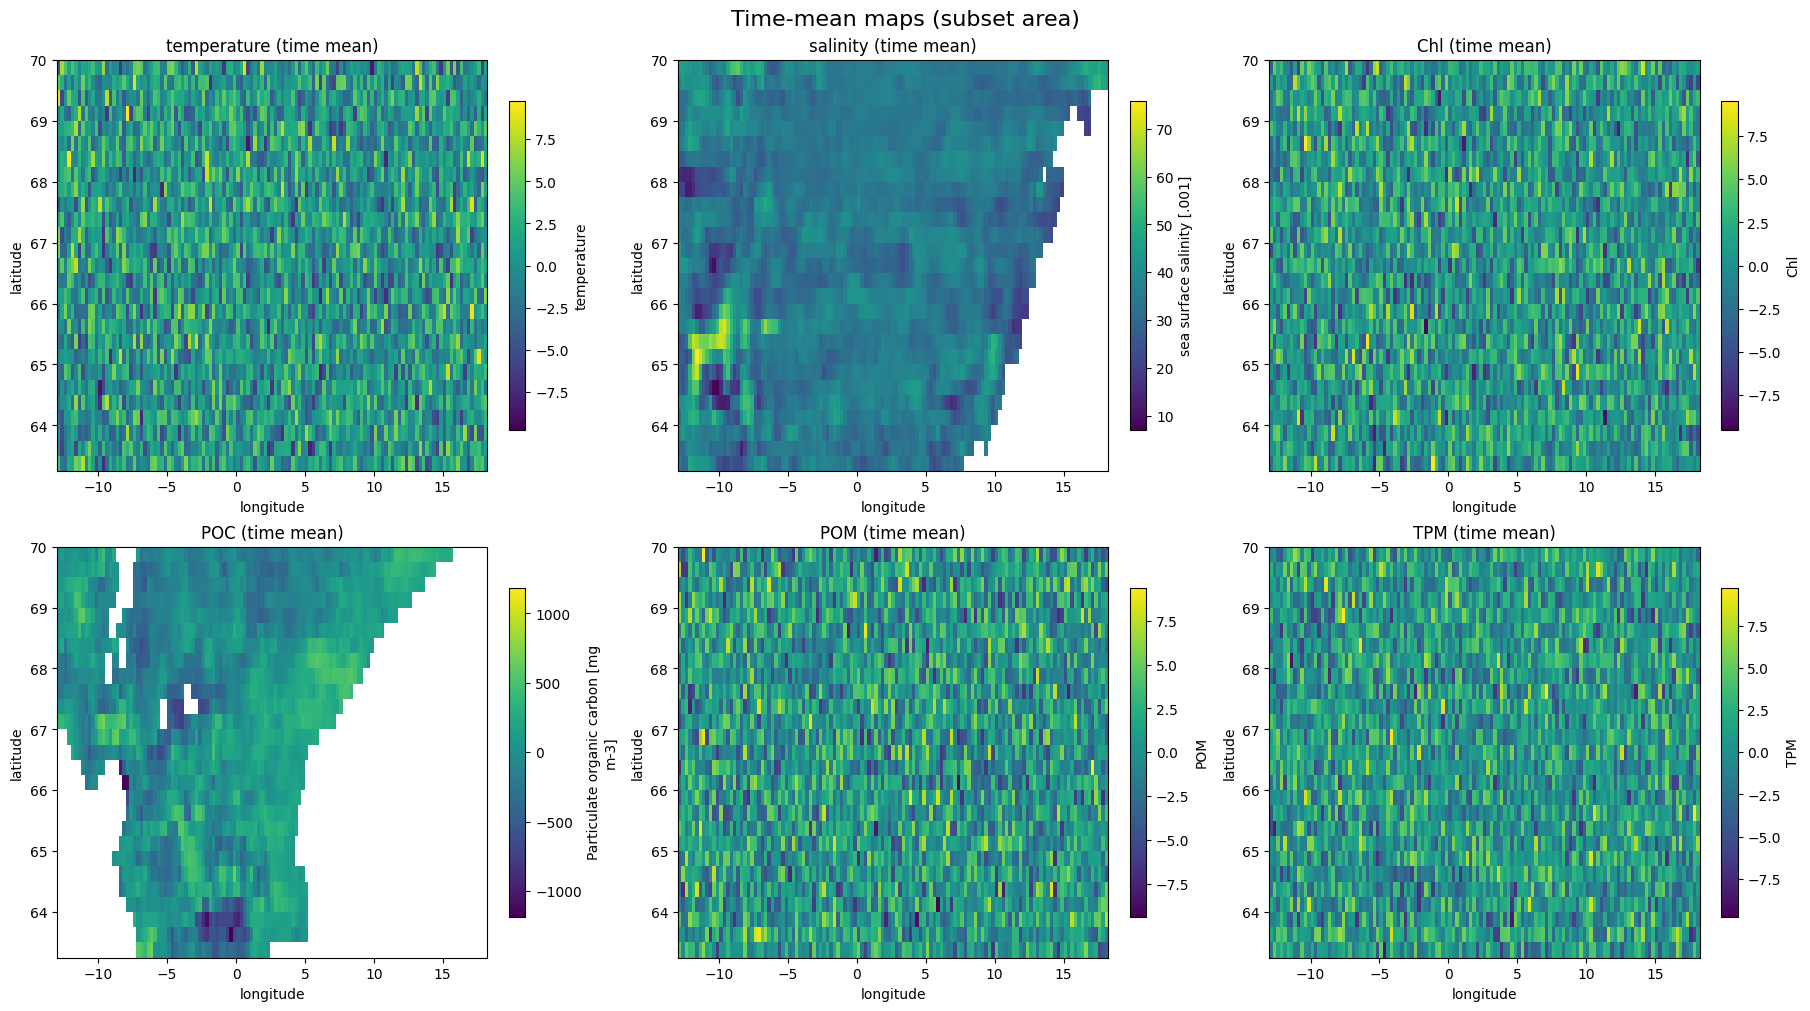

In [12]:
# ============================================================
# EXPLORATORY VISUALISATION OF RAW INPUT DATA
# ============================================================
# Best practice: inspect inputs before running the model.
# This cell produces:
#   1. Six spatial time-mean maps showing geographic patterns
#   2. Temperature/salinity and food-variable time series at
#      the central pixel to check temporal variability.
# If a variable looks flat/random it came from fake-data fallback and model results for it will not be physical.


# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    # plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()

    # # Time series at a representative point (central pixel)
    # lat0 = float(ds_daily.latitude.mean().values)
    # lon0 = float(ds_daily.longitude.mean().values)
    # point = ds_daily.sel(latitude=lat0, longitude=lon0, method='nearest')

    # fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

    # # Temperature & Salinity
    # if 'temperature' in point and 'salinity' in point:
    #     axs[0].plot(point['time'].values, point['temperature'].values, label='Temperature (°C)')
    #     axs[0].plot(point['time'].values, point['salinity'].values, label='Salinity (psu)')
    #     axs[0].set_ylabel("Temperature / Salinity")
    #     axs[0].legend()
    #     axs[0].grid(True)
    # else:
    #     axs[0].text(0.5, 0.5, "Temperature or Salinity missing", ha='center')

    # # Food-related variables
    # food_vars = [v for v in ['Chl', 'POC', 'POM', 'TPM'] if v in point]
    # if food_vars:
    #     for v in food_vars:
    #         axs[1].plot(point['time'].values, point[v].values, label=v)
    #     axs[1].set_ylabel("Concentration")
    #     axs[1].legend()
    #     axs[1].grid(True)
    # else:
    #     axs[1].text(0.5, 0.5, "No food variables found", ha='center')

    # plt.xlabel("time")
    # plt.suptitle(f"Time series at nearest point to (lat={lat0:.3f}, lon={lon0:.3f})")
    # plt.savefig("ds_daily_point_timeseries.png", dpi=150)
    # plt.show()

In [13]:

# Prepare variables to plot
vars_to_show = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
available_vars = [v for v in vars_to_show if v in ds_daily]

if len(available_vars) == 0:
    print("No variables available in ds_daily to create folium map.")
else:
    # Map center and bounds
    lat_vals = ds_daily.latitude.values
    lon_vals = ds_daily.longitude.values
    lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
    lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())
    bounds = [[lat_min, lon_min], [lat_max, lon_max]]
    center = [(lat_min + lat_max) / 2.0, (lon_min + lon_max) / 2.0]

    m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

    # Helper to make PNG data URL from 2D array
    def array_to_dataurl(arr2d, cmap_name='viridis', vmin=None, vmax=None, nodata_color=(0, 0, 0, 0)):
        """Convert a 2D numpy array (lat x lon, NaNs allowed) to a data URL PNG using a colormap.
           The array is assumed to be ordered lat increasing -> we flip it vertically for image overlay."""
        mask = np.isnan(arr2d)
        arr = np.array(arr2d, dtype=float)
        if vmin is None:
            vmin = np.nanpercentile(arr, 2) if np.isfinite(np.nanpercentile(arr, 2)) else np.nanmin(arr)
        if vmax is None:
            vmax = np.nanpercentile(arr, 98) if np.isfinite(np.nanpercentile(arr, 98)) else np.nanmax(arr)
        # Avoid zero-range
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
            vmin = np.nanmin(arr)
            vmax = np.nanmax(arr)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
                vmax = vmin + 1.0

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
        cmap = mpl.cm.get_cmap(cmap_name)
        mapped = cmap(norm(np.flipud(arr)))  # RGBA float [0,1], flipud so top of image == max latitude

        # Apply transparency where data is nan
        alpha = mapped[..., 3]
        alpha[ np.flipud(mask) ] = 0.0  # flip mask same as data flip
        mapped[..., 3] = alpha

        # Convert to 8-bit RGBA
        rgba8 = (mapped * 255).astype(np.uint8)
        im = Image.fromarray(rgba8, mode='RGBA')

        bio = io.BytesIO()
        im.save(bio, format='PNG')
        b64 = base64.b64encode(bio.getvalue()).decode('ascii')
        return f"data:image/png;base64,{b64}"

    # Optional custom colormaps per variable
    var_cmaps = {
        'temperature': 'viridis',
        'salinity': 'plasma',
        'Chl': 'YlGn',
        'POC': 'YlOrBr',
        'POM': 'OrRd',
        'TPM': 'inferno'
    }

    # Create and add an ImageOverlay per variable (time-mean)
    first_added = False
    for var in available_vars:
        try:
            da_mean = ds_daily[var].mean(dim='time').values
            # Ensure 2D
            if da_mean.ndim != 2:
                # Try to squeeze (sometimes coords order differs)
                da_mean = np.squeeze(da_mean)
                if da_mean.ndim != 2:
                    print(f"Skipping {var}: not 2D after squeeze")
                    continue

            cmap = var_cmaps.get(var, 'viridis')
            vmin = np.nanpercentile(da_mean, 2) if np.isfinite(np.nanpercentile(da_mean, 2)) else None
            vmax = np.nanpercentile(da_mean, 98) if np.isfinite(np.nanpercentile(da_mean, 98)) else None
            data_url = array_to_dataurl(da_mean, cmap_name=cmap, vmin=vmin, vmax=vmax)

            overlay = folium.raster_layers.ImageOverlay(
                name=var,
                image=data_url,
                bounds=bounds,
                opacity=0.8 if not first_added else 1.0,
                interactive=True,
                cross_origin=False,
                zindex=1
            )
            overlay.add_to(m)
            first_added = True

            # Add a small legend using branca linear colormap (approx)
            try:
                # create a linear colormap using vmin/vmax
                lc = linear.__getattribute__(cmap).scale(
                    float(np.nanmin(da_mean)), float(np.nanmax(da_mean))
                )
                lc.caption = f"{var} (time mean)"
                lc.add_to(m)
            except Exception:
                # fallback simple legend using viridis
                pass

        except Exception as e:
            print(f"Failed to add overlay for {var}: {e}")

    # Add LayerControl
    folium.LayerControl(collapsed=False).add_to(m)

    # Inject JavaScript to convert overlay checkboxes into radio buttons so only one overlay can be active at a time.
    # This waits for the layers control to be present and then converts overlay inputs (which are checkboxes)
    # into radio inputs sharing the same name 'overlayGroup', making them mutually exclusive.
    js = """
    <script>
    function makeOverlaysRadio(){
      var lc = document.getElementsByClassName('leaflet-control-layers')[0];
      if(!lc) { setTimeout(makeOverlaysRadio, 200); return; }
      // Get all inputs inside the layers control
      var inputs = lc.querySelectorAll('input');
      // Convert overlay checkboxes to radios. Base layers are already radios (type="radio")
      // Overlays usually have type="checkbox" and are after a <hr> in the control; we simply convert all checkboxes to radios.
      var overlayName = 'overlayGroup';
      for(var i=0; i<inputs.length; i++){
        var inp = inputs[i];
        if(inp.type === 'checkbox'){
          inp.type = 'radio';
          inp.name = overlayName;
        }
      }
    }
    // Run shortly after map init
    setTimeout(makeOverlaysRadio, 500);
    </script>
    """
    from folium import Element
    m.get_root().html.add_child(Element(js))

    # Save to file and report
    out_html = "ds_daily_folium_map.html"
    # m.save(out_html)
    print(f"Folium map saved to {out_html}")


# If in a Jupyter environment, display inline (will be ignored otherwise)
try:
    display(m)
except Exception:
    pass

Folium map saved to ds_daily_folium_map.html


/tmp/ipykernel_117534/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_117534/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_117534/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_117534/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated

In [14]:
# ============================================================
# RECHUNK FOR OPTIMAL DASK PERFORMANCE
# ============================================================
# After subsetting and interpolation, Dask's internal chunk
# boundaries may be irregular. Rechunking reorganises them into
# uniform tiles:
#   time: -1  -> one chunk for the full time axis (required;
#               ShellSIM cannot be split along time)
#   lat: 80, lon: 110 -> spatial tile footprint
# After rechunking each Dask task processes one complete tile
# with no overlap, minimising scheduler overhead.
#
# RAM tip: if you encounter MemoryErrors, halve lat/lon chunk
# sizes. Each chunk ~ lat * lon * time_steps * 8 bytes * n_vars.

# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size

print("Rechunking dataset for optimal performance")
ds_daily = ds_daily.chunk({
    'time': -1,       # Keep all time steps together
    'latitude': 80,   # Process 80 latitudes at once
    'longitude': 110  # Process 110 longitudes at once
})
print("Rechunked dataset")
print(ds_daily.chunks)

Rechunking dataset for optimal performance
Rechunked dataset
Frozen({'time': (335,), 'latitude': (27,), 'longitude': (110, 15)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [16]:
# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
# N_STATES  = 11 : internal state variables integrated by pyfabm
# N_DIAGS   =  2 : diagnostic outputs (TFW, SL) computed from
#                  states but not part of the ODE system
# N_OUTPUTS = 13 : total rows returned per pixel per call
#
# VARIABLE_NAMES order must exactly match the row order filled
# inside the time loop: rows 0-10 = 11 state variables,
# row 11 = TFW, row 12 = SL.
#
# run_fabm_at_point_full:
#   Accepts 6 numpy arrays (one per forcing, length=time_horizon_len)
#   plus a log filename. Initialises pyfabm, steps forward one
#   day at a time using forward-Euler (state += rate * 86400 s),
#   and returns a (13, time) array.
#   NaN/non-finite inputs => NaN output (land/missing data guard).
# Big picture: apply_ufunc (below) calls this for every pixel.

# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

N_STATES  = 11   # pyfabm internal state variables (model.state[:] length)
N_DIAGS   = 2    # diagnostic outputs: TFW (row 11), SL (row 12)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 — total rows returned per pixel

VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3',
    'Chl', 'POC', 'POM', 'TPM', 'O2',   # rows 0–10  (state variables)
    'TFW', 'SL'                           # rows 11–12 (diagnostics)
]

def run_fabm_at_point_full(T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts, log_filename):
    """
    Runs FABM time-loop for a single spatial point.
    Returns a 2D array of shape (N_OUTPUTS=13, time_horizon_len).
    Rows 0-10: pyfabm state variables.
    Row 11:    TFW diagnostic (g).
    Row 12:    Shell Length diagnostic (cm).
    NaN inputs (land/missing) return a full NaN array.
    """
    # Guard: reject pixels with NaN or non-finite input
    all_inputs = [T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)

    try:
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):

                model = pyfabm.Model("/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/fabm.yaml")

                # Static forcing (time-invariant)
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value  = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value  = 0.0
                model.dependencies["number_of_days_since_start_of_the_year"].value = 0.0

                # Initial conditions from day-0 values
                model.dependencies["temperature"].value        = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[0])
                model.findStateVariable('POC1/POC').value      = float(POC_ts[0])
                model.findStateVariable('POM1/POM').value      = float(POM_ts[0])
                model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[0])

                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")

        # Output array: N_OUTPUTS rows (13), one column per day
        # NOTE: must use N_OUTPUTS here — NOT N_STATES.
        # Using N_STATES (11) would leave rows 11-12 uninitialised
        # and cause the broadcast shape mismatch error.
        outputs = np.zeros((N_OUTPUTS, time_horizon_len))
        
        for nd in range(time_horizon_len):
            model.dependencies["temperature"].value        = float(T_ts[nd])
            model.dependencies["practical_salinity"].value = float(S_ts[nd])
            model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
            model.findStateVariable('POC1/POC').value       = float(POC_ts[nd])
            model.findStateVariable('POM1/POM').value       = float(POM_ts[nd])
            model.findStateVariable('TPM1/TPM').value       = float(TPM_ts[nd])
        
            # getRates() returns exactly 11 values (one per state variable).
            # Assign back to model.state directly — identical to the original
            # single-pixel notebook. No slicing, no broadcasting.
            state_rates = model.getRates()
            model.state[:] += state_rates * 86400.0
        
            # Copy the 11 state values into rows 0-10 of the output array.
            # Use np.array() to force a detached copy — avoids writing a live
            # pyfabm view into the numpy array which can cause shape conflicts.
            outputs[:N_STATES, nd] = np.array(model.state[:])
        
            # Rows 11-12: diagnostics (not part of model.state)
            outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
            outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value
        
        return outputs  # shape (13, time_horizon_len)

    except RuntimeError:
        warnings.warn(f"FABM failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)

    except Exception as e:
        warnings.warn(f"FABM error: {str(e)}")
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)

## Most optimal processing method:  parallelize over the spatial dimensions (latitude, longitude) using xarray.apply_ufunc.  
chunking only the spatial dimensions (latitude and longitude) tells Dask to split the map into tiles, but keep the full time series for each pixel intact.

# Method 2 on Memory optimization    
Runs in 1:37 ish for start = '02-06-2021' end = '04-06-2021'

In [33]:

# ============================================================
# CONFIG
# ============================================================
time_horizon_len = ds_daily.time.size
output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

N_STATES = 11

STATE_NAMES = [
    'soft_tissue_energy',
    'shell_energy',
    'aging',
    'C1',
    'C2',
    'C3',
    'Chl_state',
    'POC_state',
    'POM_state',
    'TPM_state',
    'O2'
]

# ============================================================
# CHUNK INFO
# ============================================================
try:
    lat_chunks = ds_daily.chunks['latitude']
    lon_chunks = ds_daily.chunks['longitude']
except Exception:
    raise RuntimeError(
        "ds_daily must be Dask-backed and chunked in latitude/longitude"
    )

lat_indices = np.cumsum([0] + list(lat_chunks))
lon_indices = np.cumsum([0] + list(lon_chunks))

total_lat = int(ds_daily.sizes["latitude"])
total_lon = int(ds_daily.sizes["longitude"])

# ============================================================
# CREATE OUTPUT FILE ONCE
# ============================================================
if os.path.exists(output_file_name):
    os.remove(output_file_name)

nc = netCDF4.Dataset(output_file_name, "w", format="NETCDF4")

nc.createDimension("time", time_horizon_len)
nc.createDimension("latitude", total_lat)
nc.createDimension("longitude", total_lon)

# coordinates
time_var = nc.createVariable("time", "f8", ("time",))

time_seconds = (
    pd.to_datetime(ds_daily.time.values)
    .astype("datetime64[s]")
    .astype(np.int64)
)

time_var[:] = time_seconds
time_var.units = "seconds since 1970-01-01 00:00:00"
time_var.calendar = "standard"

lat_var = nc.createVariable("latitude", "f4", ("latitude",))
lat_var[:] = ds_daily.latitude.values.astype(np.float32)

lon_var = nc.createVariable("longitude", "f4", ("longitude",))
lon_var[:] = ds_daily.longitude.values.astype(np.float32)

# state variables
for name in STATE_NAMES:
    nc.createVariable(
        name,
        "f4",
        ("time", "latitude", "longitude"),
        zlib=True,
        complevel=4,
        fill_value=np.float32(np.nan),
    )

nc.sync()
nc.close()

print(f"Starting batched computation -> {output_file_name}")

# ============================================================
# PROCESS CHUNKS
# ============================================================
for i in range(len(lat_chunks)):

    lat_start = int(lat_indices[i])
    lat_end = int(lat_indices[i + 1])

    for j in range(len(lon_chunks)):

        lon_start = int(lon_indices[j])
        lon_end = int(lon_indices[j + 1])

        print(
            f"\nBatch "
            f"Lat {i+1}/{len(lat_chunks)} "
            f"({lat_start}:{lat_end}) "
            f"Lon {j+1}/{len(lon_chunks)} "
            f"({lon_start}:{lon_end})"
        )

        ds_subset = ds_daily.isel(
            latitude=slice(lat_start, lat_end),
            longitude=slice(lon_start, lon_end)
        )

        result_full_batch = xr.apply_ufunc(
            run_fabm_at_point_full,

            ds_subset["temperature"],
            ds_subset["salinity"],
            ds_subset["Chl"],
            ds_subset["POC"],
            ds_subset["POM"],
            ds_subset["TPM"],

            input_core_dims=[["time"]] * 6,
            output_core_dims=[["state", "time"]],

            exclude_dims={"time"},

            vectorize=True,
            dask="parallelized",

            output_dtypes=[float],

            kwargs={
                "log_filename": RUN_LOG_FILENAME
            },

            dask_gufunc_kwargs={
                "allow_rechunk": True,
                "output_sizes": {
                    "state": N_STATES,
                    "time": time_horizon_len
                }
            }
        )

        result_full_batch = result_full_batch.assign_coords(
            time=ds_subset.time
        )

        result_full_batch = result_full_batch.assign_coords(
            state=STATE_NAMES
        )

        result_dataset_batch = result_full_batch.to_dataset(dim="state")

        with ProgressBar():
            result_dataset_batch.load()

        # ====================================================
        # DEBUG SUMMARY
        # ====================================================
        print("\nChunk output summary:")

        for state_name in STATE_NAMES:

            arr = result_dataset_batch[state_name].values

            total = arr.size
            nans = np.isnan(arr).sum()

            try:
                arr_min = np.nanmin(arr)
                arr_max = np.nanmax(arr)
            except ValueError:
                arr_min = np.nan
                arr_max = np.nan

            print(
                f"{state_name:20s} "
                f"NaN%={(100*nans/total):6.2f} "
                f"min={arr_min} "
                f"max={arr_max}"
            )

        # ====================================================
        # WRITE TILE INTO EXISTING FILE
        # ====================================================
        nc = netCDF4.Dataset(output_file_name, "r+")

        try:

            for state_name in STATE_NAMES:

                da = result_dataset_batch[state_name]

                arr = (
                    da.transpose(
                        "time",
                        "latitude",
                        "longitude"
                    )
                    .values
                    .astype(np.float32)
                )

                print(
                    f"Writing {state_name} "
                    f"shape={arr.shape} "
                    f"NaNs={np.isnan(arr).sum()}"
                )

                nc.variables[state_name][
                    :,
                    lat_start:lat_end,
                    lon_start:lon_end
                ] = arr

            nc.sync()

        finally:
            nc.close()

        del result_full_batch
        del result_dataset_batch
        del ds_subset

        gc.collect()

print(
    f"\n✅ Success: all batches processed and saved to "
    f"{output_file_name}"
)

Starting batched computation -> gridded_oyster_output_ALL_STATES_batched.nc

Batch Lat 1/1 (0:27) Lon 1/2 (0:110)
[########################################] | 100% Completed | 28.99 ss

Chunk output summary:
soft_tissue_energy   NaN%= 97.64 min=835.2693312937315 max=62524.41312635948
shell_energy         NaN%= 97.64 min=526.3469129788559 max=20250.531094431975
aging                NaN%= 97.64 min=1.0 max=1.0
C1                   NaN%= 97.64 min=-5.904530183527903e-20 max=99.29272408545197
C2                   NaN%= 97.64 min=-1.8347684410756374e-21 max=48.96984789613802
C3                   NaN%= 97.64 min=0.0 max=99.99999999999994
Chl_state            NaN%= 97.64 min=-21.316066459478773 max=21.527611429998075
POC_state            NaN%= 97.64 min=-2356.065179007394 max=1637.2365646362305
POM_state            NaN%= 97.64 min=-19.649124765151235 max=20.804948552000624
TPM_state            NaN%= 97.64 min=-20.020667836616713 max=20.977368772379865
O2                   NaN%= 97.64 min=10.0

In [26]:
# # Assumes ds_daily, run_fabm_at_point_full, and RUN_LOG_FILENAME are defined in the environment.

# # ---------- configuration (keep in sync with your model) ----------
# time_horizon_len = int(ds_daily.sizes['time'])
# output_file_name = 'gridded_oyster_output_ALL_STATES_batched.nc'

# N_OUTPUTS_BATCH = 13
# STATE_NAMES = [
#     'soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3',
#     'Chl', 'POC', 'POM', 'TPM', 'O2',
#     'TFW', 'SL'
# ]
# if len(STATE_NAMES) != N_OUTPUTS_BATCH:
#     raise ValueError('STATE_NAMES length mismatch')



# total_lat = int(ds_daily.sizes['latitude'])
# total_lon = int(ds_daily.sizes['longitude'])

# # Ensure ds_daily has chunk info for spatial dims
# try:
#     lat_chunks = ds_daily.chunks['latitude']
#     lon_chunks = ds_daily.chunks['longitude']
# except Exception as e:
#     raise RuntimeError('ds_daily must be Dask-backed with chunks for latitude and longitude') from e

# lat_indices = np.cumsum([0] + list(lat_chunks))
# lon_indices = np.cumsum([0] + list(lon_chunks))

# # ---------- Create the empty netCDF file with full dimensions ----------
# if os.path.exists(output_file_name):
#     os.remove(output_file_name)

# nc = netCDF4.Dataset(output_file_name, 'w', format='NETCDF4')
# # dimensions
# nc.createDimension('time', time_horizon_len)
# nc.createDimension('latitude', total_lat)
# nc.createDimension('longitude', total_lon)

# # coordinate variables
# time_var = nc.createVariable('time', 'f8', ('time',))
# # convert xarray times to POSIX seconds (int64) then store as float64
# time_seconds = pd.to_datetime(ds_daily['time'].values).astype('datetime64[s]').astype('int64')
# time_var[:] = time_seconds
# time_var.units = 'seconds since 1970-01-01T00:00:00Z'
# time_var.calendar = 'standard'

# lat_var = nc.createVariable('latitude', 'f4', ('latitude',))
# lat_var[:] = ds_daily['latitude'].values.astype(np.float32)
# lat_var.units = getattr(ds_daily['latitude'], 'units', 'degrees_north')

# lon_var = nc.createVariable('longitude', 'f4', ('longitude',))
# lon_var[:] = ds_daily['longitude'].values.astype(np.float32)
# lon_var.units = getattr(ds_daily['longitude'], 'units', 'degrees_east')

# # data variables: one per state, dims = (time, latitude, longitude)
# for name in STATE_NAMES:
#     # use compression and a fill_value (NaN)
#     nc.createVariable(name, 'f4', ('time', 'latitude', 'longitude'),
#                       zlib=True, complevel=4, fill_value=np.float32(np.nan))

# nc.sync()
# nc.close()

# # ---------- Process tiles and write into the pre-created file ----------
# print(f'Starting batched computation -> {output_file_name}')

# for i in range(len(lat_chunks)):
#     lat_start = int(lat_indices[i])
#     lat_end   = int(lat_indices[i+1])
#     for j in range(len(lon_chunks)):
#         lon_start = int(lon_indices[j])
#         lon_end   = int(lon_indices[j+1])

#         ds_subset = ds_daily.isel(
#             latitude=slice(lat_start, lat_end),
#             longitude=slice(lon_start, lon_end)
#         )

#         print(f'  Batch Lat {i+1}/{len(lat_chunks)} ({lat_start}:{lat_end}), '
#               f'Lon {j+1}/{len(lon_chunks)} ({lon_start}:{lon_end})')

#         result_full_batch = xr.apply_ufunc(
#             run_fabm_at_point_full,
#             ds_subset['temperature'],
#             ds_subset['salinity'],
#             ds_subset['Chl'],
#             ds_subset['POC'],
#             ds_subset['POM'],
#             ds_subset['TPM'],
#             input_core_dims=[['time']] * 6,
#             output_core_dims=[['state', 'time']],
#             exclude_dims={'time'},
#             dask='parallelized',
#             vectorize=True,
#             output_dtypes=[float],
#             kwargs={'log_filename': RUN_LOG_FILENAME},
#             dask_gufunc_kwargs={
#                 'allow_rechunk': True,
#                 'output_sizes': {'state': N_OUTPUTS_BATCH, 'time': time_horizon_len}
#             }
#         )

#         # assign coords and convert to dataset with per-state variables
#         result_full_batch = result_full_batch.assign_coords(time=ds_subset.time)
#         result_full_batch = result_full_batch.assign_coords(state=STATE_NAMES)
#         result_dataset_batch = result_full_batch.to_dataset(dim='state')

#         # Compute/load the dask arrays into memory
#         with ProgressBar():
#             result_dataset_batch.load()

#         # ── Transpose and write each state variable into the pre-created NetCDF ──
#         # After apply_ufunc + to_dataset the arrays may come out as
#         # (latitude, longitude, time) rather than (time, latitude, longitude).
#         # We explicitly transpose to (time, lat_tile, lon_tile) before writing
#         # so the netCDF4 slice assignment always matches the declared dimension order.
#         nc = netCDF4.Dataset(output_file_name, 'r+')
#         try:
#             for state_name in STATE_NAMES:
#                 if state_name not in result_dataset_batch:
#                     continue

#                 da = result_dataset_batch[state_name]

#                 # Identify dimension names actually present on this DataArray
#                 dims = list(da.dims)

#                 # Work out which dim is time vs spatial
#                 time_dim  = next((d for d in dims if 'time'      in d.lower()), None)
#                 lat_dim   = next((d for d in dims if 'lat'       in d.lower()), None)
#                 lon_dim   = next((d for d in dims if 'lon'       in d.lower()), None)

#                 if time_dim is None or lat_dim is None or lon_dim is None:
#                     raise ValueError(
#                         f"Cannot identify time/lat/lon dims for '{state_name}'. "
#                         f"Found dims: {dims}"
#                     )

#                 # Reorder to (time, latitude, longitude) regardless of current order
#                 arr = da.transpose(time_dim, lat_dim, lon_dim).values.astype(np.float32)

#                 # Validate shape before writing
#                 if arr.shape[0] != time_horizon_len:
#                     raise ValueError(
#                         f"time length mismatch for '{state_name}': "
#                         f"got {arr.shape[0]}, expected {time_horizon_len}. "
#                         f"Full shape after transpose: {arr.shape}"
#                     )

#                 nc.variables[state_name][:, lat_start:lat_end, lon_start:lon_end] = arr
#             nc.sync()
#         finally:
#             nc.close()

#         # del result_full_batch, result_dataset_batch, ds_subset
#         gc.collect()

# print(f'SUCCESS: All batches processed and saved to {output_file_name}')

In [34]:

result_dataset_batch

NameError: name 'result_dataset_batch' is not defined

In [18]:
result_dataset = result_full_batch

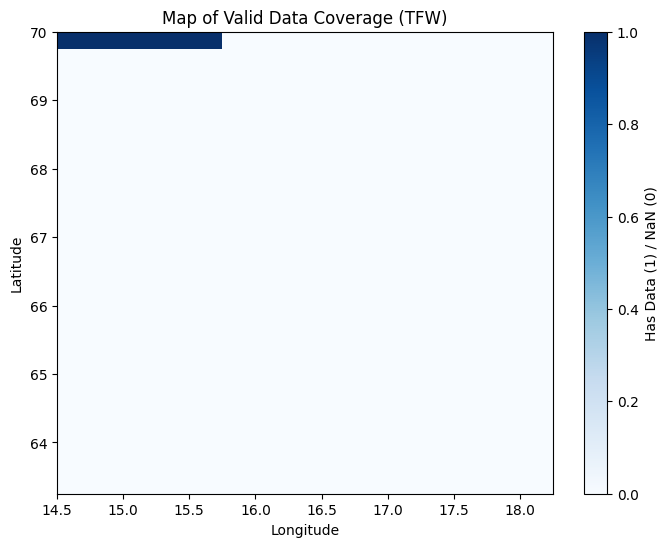


Examine the map above to visually pick a coordinate (blue area) to plot.


In [27]:
# ============================================================
# DATA COVERAGE MAP
# ============================================================
# Creates a spatial map showing which pixels contain valid
# (non-NaN) model output vs which are all-NaN (land or where
# all inputs were missing). Blue pixels = valid model output;
# white pixels = no data. Use this map to identify regions
# suitable for aquaculture analysis.

# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

TFW and SL are FABM diagnostics (Oyster/TFW, Oyster/Shell_Length) computed inside the model — and the saved file (CELL 40) only writes the 11 state variables, with TFW/SL commented out. So ds_out genuinely has no TFW/SL. To fix the dashboard I need to re-derive them from the saved states (soft_tissue_energy, shell_energy). Let me check whether the ShellSIM/FABM source with the exact allometric constants is available in the workspace